# Binomial-Beta Model of the Marth-Fox Matchup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sc
import sympy as sp

# Set random seed
seed = 6420
rng = np.random.default_rng(seed)

## Analytical Approach

We can find the exact posterior since the Beta prior can form a conjugate distribution with the posterior with respect to the Binomial likelihood. For simplicity (and to shorten execution time), we can find our posterior kernel to show that such a likelihood and prior result in a Beta posterior.

In [2]:
alpha, beta, theta = sp.symbols('alpha beta theta', real=True, positive=True)
x, n = sp.symbols('x n', integer=True, positive=True)

prior = (theta**(alpha - 1) * (1 - theta)**(beta - 1))
likelihood = theta**x * (1 - theta)**(n - x)

posterior = prior * likelihood
sp.simplify(posterior)


theta**(alpha + x - 1)*(1 - theta)**(beta + n - x - 1)

Prior: 6/4, Posterior Mean: 0.70
Prior: 5/5, Posterior Mean: 0.65
Prior: 4/6, Posterior Mean: 0.60


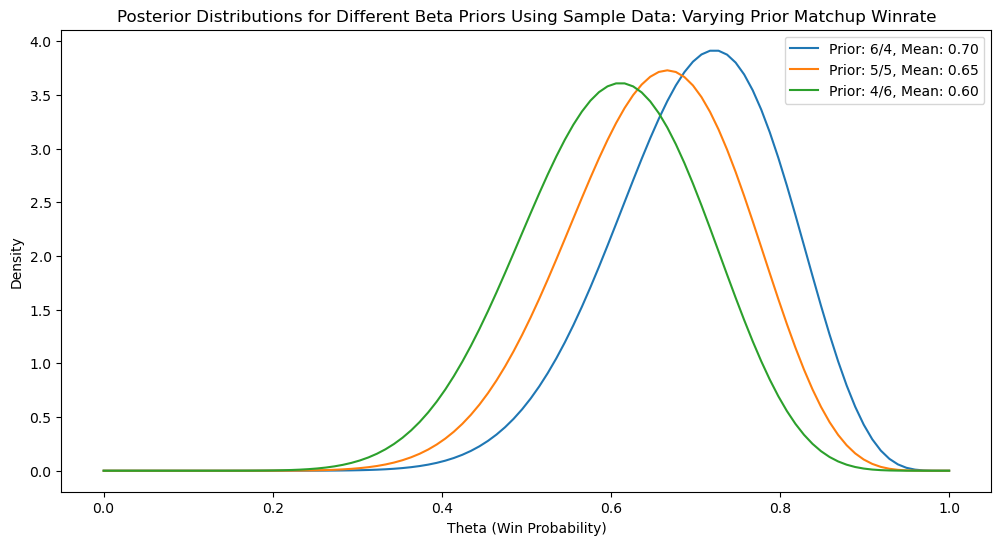

In [3]:
# Assume we have observed 8 wins out of 10 matches
x_obs = 8
n_obs = 10

# Assume we have three beta priors: 60/40, 50/50, and 40/60
priors = [(6, 4), (5, 5), (4, 6)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0, 1, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors Using Sample Data: Varying Prior Matchup Winrate')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/posterior_different_beta_priors_sample_data.png')
plt.show()

We can also try different strengths of beta priors, depending on how confident we are in a matchup spread. For example, let us try different beta priors where the expected matchup is 50/50 (i.e. alpha=beta)

Prior: 1/1, Posterior Mean: 0.75
Prior: 10/10, Posterior Mean: 0.60
Prior: 100/100, Posterior Mean: 0.51


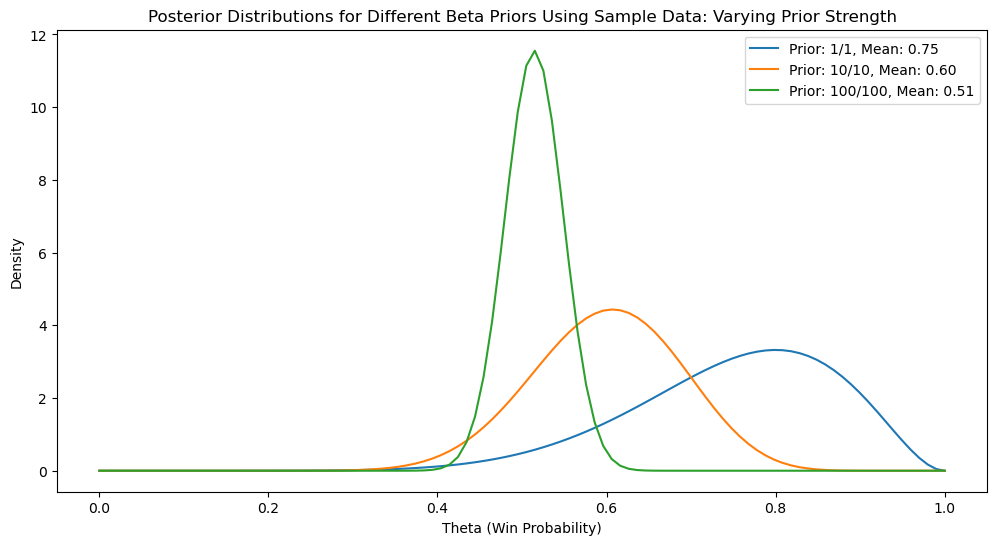

In [4]:
# Assume we have observed 8 wins out of 10 matches
x_obs = 8
n_obs = 10

# Assume our priors vary in strength: 1/1 (non-informative), 10/10 (moderately informative), and 100/100 (strongly informative)
priors = [(1, 1), (10, 10), (100, 100)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0, 1, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors Using Sample Data: Varying Prior Strength')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/posterior_beta_priors_sample_data.png')
plt.show()

Using the observed data, we can plot the posterior distributions for various strengths of a "50/50" prior.

In [5]:
# Read from fox_marth_competitive.csv
data = pd.read_csv('data/fox_marth_competitive.csv')
print(data.head())

   id               stage winning_character
0   1        YOSHIS_STORY               FOX
1   2  FOUNTAIN_OF_DREAMS             MARTH
2   3   FINAL_DESTINATION               FOX
3   4   FINAL_DESTINATION             MARTH
4   5        YOSHIS_STORY               FOX


In [6]:
# Create a new column 'marth_wins' that is 1 if MARTH is the winning_character, else 0
data['marth_wins'] = (data['winning_character'] == 'MARTH').astype(int)
marth_wins = data['marth_wins'].sum()
total_matches = len(data)
print(f"Marth Wins: {marth_wins}, Total Matches: {total_matches}")

Marth Wins: 133582, Total Matches: 270974


Because of the large quantity of data, we expect this to overpower the prior due to the nature of how the posterior parameters are calculated.

Prior: 1/1, Posterior Mean: 0.49
Prior: 10/10, Posterior Mean: 0.49
Prior: 100/100, Posterior Mean: 0.49


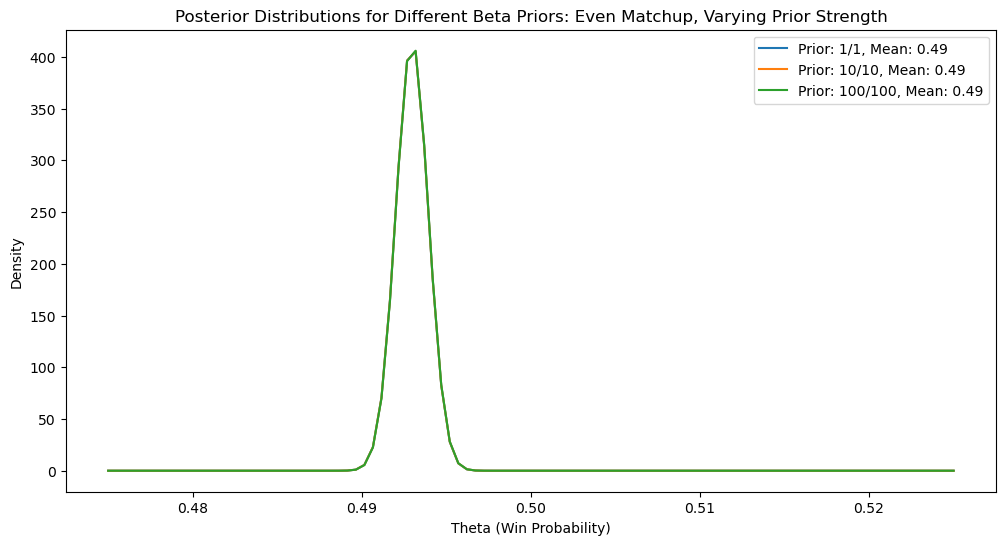

In [7]:
x_obs = marth_wins
n_obs = total_matches

priors = [(1, 1), (10, 10), (100, 100)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0.475, 0.525, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors: Even Matchup, Varying Prior Strength')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/posterior_beta_priors_varying_strength.png')
plt.show()

Using varying priors, we can see how the observed data renders the priors effectively irrelevant when evaluating the posterior.

Prior: 6/4, Posterior Mean: 0.49
Prior: 5/5, Posterior Mean: 0.49
Prior: 4/6, Posterior Mean: 0.49


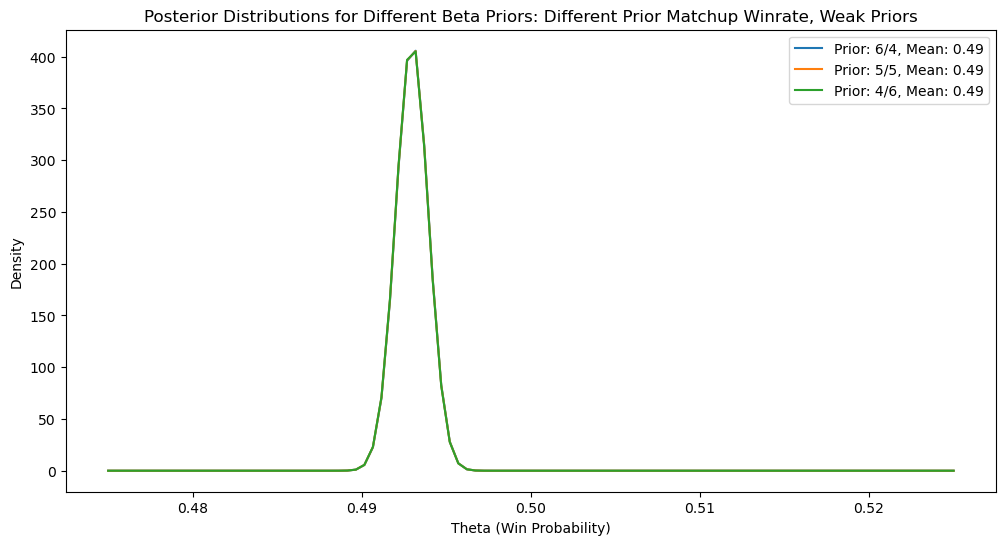

In [8]:
# Assume we have three beta priors: 60/40, 50/50, and 40/60
priors = [(6, 4), (5, 5), (4, 6)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0.475, 0.525, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors: Different Prior Matchup Winrate, Weak Priors')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/posterior_beta_priors_varying_matchup_winrate.png')
plt.show()

Only when we greatly strengthen our priors do we see more significant deviation in the posteriors (although slight).

Prior: 600/400, Posterior Mean: 0.49
Prior: 500/500, Posterior Mean: 0.49
Prior: 400/600, Posterior Mean: 0.49


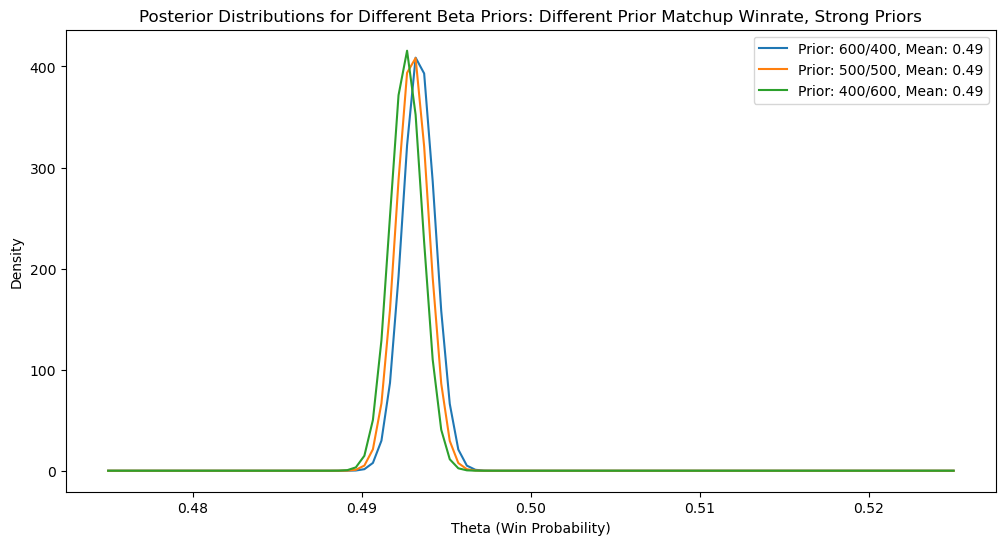

In [9]:
# Assume we have three beta priors: 60/40, 50/50, and 40/60
# However, we will make these priors stronger
priors = [(600, 400), (500, 500), (400, 600)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0.475, 0.525, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors: Different Prior Matchup Winrate, Strong Priors')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/posterior_beta_priors_varying_matchup_winrate_and_strength.png')
plt.show()